In [1]:
import pandas as pd 
import seaborn as sns
df= pd.read_csv("custdata.tsv" , sep="\t")


### Correlations before Data Cleaning

In [2]:
df.head()

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
0,2068,F,NaN,11300,Married,True,Homeowner free and clear,False,2.0,49.0,Michigan
1,2073,F,NaN,0,Married,True,Rented,True,3.0,40.0,Florida
2,2848,M,True,4500,Never Married,False,Rented,True,3.0,22.0,Georgia
3,5641,M,True,20000,Never Married,False,Occupied with no rent,False,0.0,22.0,New Mexico
4,6369,F,True,12000,Never Married,True,Rented,True,1.0,31.0,Florida


<Axes: >

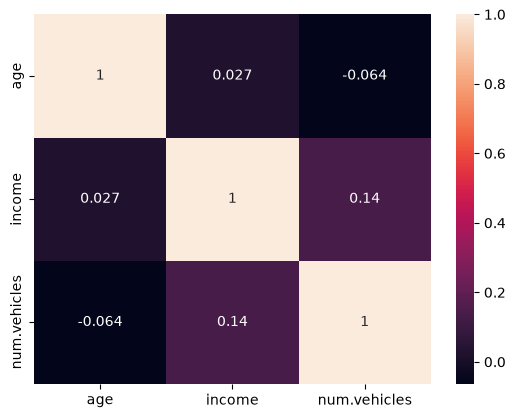

In [3]:
cols=["age", "income", "num.vehicles"]
sns.heatmap(df[cols].corr(numeric_only=True), annot=True)

#### Analysis Before Data Cleaning 
- Age vs number of vehicles : -0.064
- Age vs income : 0.027
- income vs number of vehicles : 0.14

In [4]:
df[["age", "income", "num.vehicles"]].describe()

,age,income,num.vehicles
count,1000.000000,1000.000000,944.000000
mean,51.699815,53504.771000,1.916314
std,18.863433,65478.065729,1.101618
min,0.000000,-8700.000000,0.000000
25%,38.000000,14600.000000,1.000000
50%,50.000000,35000.000000,2.000000
75%,64.000000,67000.000000,2.000000
max,146.680197,615000.000000,6.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   custid        1000 non-null   int64  
 1   sex           1000 non-null   str    
 2   is.employed   672 non-null    object 
 3   income        1000 non-null   int64  
 4   marital.stat  1000 non-null   str    
 5   health.ins    1000 non-null   bool   
 6   housing.type  944 non-null    str    
 7   recent.move   944 non-null    object 
 8   num.vehicles  944 non-null    float64
 9   age           1000 non-null   float64
 10  state.of.res  1000 non-null   str    
dtypes: bool(1), float64(2), int64(2), object(2), str(4)
memory usage: 79.2+ KB


### Looking into ages over 90

In [6]:
df[df["age"]>90]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
188,249492,F,NaN,10100,Widowed,True,NaN,NaN,NaN,93.000000,Georgia
212,287882,M,True,60000,Married,True,Rented,True,2.0,137.700030,Florida
236,330543,F,NaN,3000,Married,True,NaN,NaN,NaN,93.000000,Michigan
266,364991,F,NaN,12000,Divorced/Separated,True,Homeowner with mortgage/loan,False,1.0,123.061023,Nevada
286,397230,F,True,31200,Married,True,Rented,False,2.0,136.052160,Texas
330,459910,M,NaN,56300,Married,True,Homeowner free and clear,False,1.0,93.000000,California
361,499637,F,NaN,12000,Never Married,True,NaN,NaN,NaN,93.000000,Florida
460,628305,M,NaN,24400,Married,True,NaN,NaN,NaN,93.000000,California
593,843811,F,True,40000,Never Married,True,Homeowner with mortgage/loan,False,1.0,146.680197,Indiana
625,875771,M,False,175200,Married,True,Homeowner with mortgage/loan,False,3.0,124.845087,Arkansas


### Looking into negative incomes

In [12]:
df[df["income"]<1000]

,custid,sex,is.employed,income,marital.stat,health.ins,housing.type,recent.move,num.vehicles,age,state.of.res
55,68013,M,NaN,100,Divorced/Separated,False,NaN,NaN,NaN,28.0,California
146,181385,F,NaN,290,Married,False,Homeowner free and clear,False,2.0,28.0,Wisconsin
196,259807,M,NaN,440,Married,True,NaN,NaN,NaN,49.0,West Virginia
200,268667,M,NaN,200,Never Married,True,NaN,NaN,NaN,31.0,Pennsylvania
325,456859,M,True,80,Never Married,True,NaN,NaN,NaN,18.0,California
596,846713,M,NaN,250,Never Married,True,NaN,NaN,NaN,45.0,Florida
606,857511,F,True,30,Married,True,Homeowner with mortgage/loan,False,4.0,54.0,Illinois
638,892483,M,NaN,100,Married,True,Homeowner with mortgage/loan,False,3.0,68.0,Minnesota
674,949925,F,True,790,Married,True,Homeowner with mortgage/loan,False,2.0,44.0,Florida
738,1034979,F,NaN,750,Never Married,True,Rented,False,1.0,38.0,Indiana


#### Dropping Negative Income and Unrealistic ages

In [24]:
df_clean = df[(df["age"]>0)&(df["age"]<100)&(df["income"]>0)]

In [25]:
df_clean.describe()

,custid,income,num.vehicles,age
count,9.100000e+02,910.000000,879.000000,910.000000
mean,7.005018e+05,57683.869231,1.910125,51.851648
std,4.121213e+05,65976.684897,1.108006,17.460279
min,2.068000e+03,30.000000,0.000000,18.000000
25%,3.468315e+05,19000.000000,1.000000,39.000000
50%,7.090445e+05,38350.000000,2.000000,50.000000
75%,1.043725e+06,70162.500000,2.000000,64.000000
max,1.414286e+06,615000.000000,6.000000,93.000000


<Axes: >

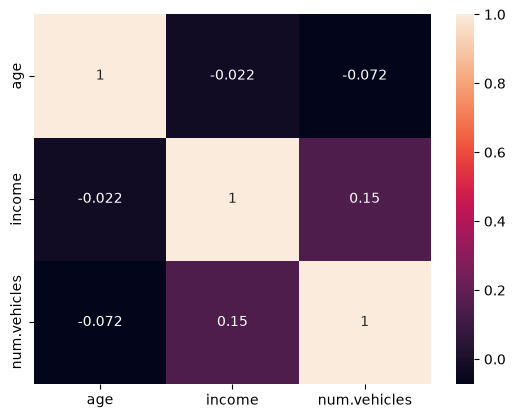

In [26]:
sns.heatmap(df_clean[cols].corr(numeric_only=True), annot=True)

### Analysis of correlations after cleaning
- Age vs number of vehicles: -0.072
  - There is no meaningful relationship between age and number of vehicles, meaning an older person is just as likely to have a car, or not, as a younger person
- Age vs. income: -0.022
  - There is no meaningful correlation between age and income, meaning that knowing the age of someone will not allow you to accurately guess their income.
- Income vs number of vehicles: 0.15
  - There is a little correlation between income and number of vehicles, meaning as income goes up number of vehicles tend to go up as well. While Income vs number of vehicles has the strongest correlation of the three correlation, it is still relatively low, indicating that there are other factors besides income when it comes to number of cars.

### Cleaning log
- Dropped 90 rows, if ages were not between the ages of 0 and 100, or if income was below 0. They were removed because the ages outside that range were impossible, and while you can have no income, it is impossible to have negative income.